# PROYECTO FINAL DATA ANALYTICS - OLIST BRAZILIAN E-COMMERCE

## Análisis Completo: EDA → Limpieza → Transformación → Análisis Estadístico


Este notebook contiene el análisis completo de los datos de Olist incluyendo:
- Exploración inicial (EDA)
- Limpieza y preparación
- Unión de múltiples datasets
- Feature engineering
- Análisis estadístico avanzado
- Segmentación RFM
- Visualizaciones

## 0. CONFIGURACIÓN INICIAL

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from scipy import stats
from scipy.stats import pearsonr, spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. CARGA DE DATOS

In [4]:
# Ruta de datos
ruta_datos = 'C:/Users/algon/Desktop/TFM/data/raw/'

# Cargar todos los datasets

orders = pd.read_csv(ruta_datos + 'olist_orders_dataset.csv')
order_items = pd.read_csv(ruta_datos + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(ruta_datos + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(ruta_datos + 'olist_order_reviews_dataset.csv')
products = pd.read_csv(ruta_datos + 'olist_products_dataset.csv')
customers = pd.read_csv(ruta_datos + 'olist_customers_dataset.csv')
sellers = pd.read_csv(ruta_datos + 'olist_sellers_dataset.csv')
geolocation = pd.read_csv(ruta_datos + 'olist_geolocation_dataset.csv')
category_translation = pd.read_csv(ruta_datos + 'product_category_name_translation.csv')

## 2. EXPLORACIÓN INICIAL (EDA)

In [5]:
def eda_quick(df, nombre):
    """Exploración rápida de un dataframe"""
    print(f"\n{'='*60}")
    print(f"{nombre.upper()}")
    print(f"{'='*60}")
    print(f"Dimensiones: {df.shape}")
    print(f"\nTipos de datos:")
    print(df.dtypes)
    print(f"\nValores nulos:")
    nulos = df.isnull().sum()
    print(nulos[nulos > 0] if nulos.sum() > 0 else "Sin valores nulos")
    print(f"\nPrimeras filas:")
    print(df.head(3))

# EDA de cada dataset
eda_quick(orders, "Orders Dataset")
eda_quick(order_items, "Order Items Dataset")
eda_quick(products, "Products Dataset")


ORDERS DATASET
Dimensiones: (99441, 8)

Tipos de datos:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object

Valores nulos:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Primeras filas:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 

## 3. LIMPIEZA DE DATOS

In [6]:
# 3.1 - Conversión de fechas

fecha_cols_orders = ['order_purchase_timestamp', 'order_approved_at', 
                     'order_delivered_carrier_date', 'order_delivered_customer_date',
                     'order_estimated_delivery_date']
for col in fecha_cols_orders:
    orders[col] = pd.to_datetime(orders[col], errors='coerce')

order_reviews['review_creation_date'] = pd.to_datetime(order_reviews['review_creation_date'], errors='coerce')
order_reviews['review_answer_timestamp'] = pd.to_datetime(order_reviews['review_answer_timestamp'], errors='coerce')

In [7]:
# 3.2 - Manejo de valores nulos

# Order reviews
order_reviews['review_comment_message'].fillna('Sin comentario', inplace=True)

# Products - dimensiones
for col in ['product_length_cm', 'product_height_cm', 'product_width_cm', 'product_weight_g']:
    products[col].fillna(products[col].median(), inplace=True)

In [8]:
# 3.3 - Limpieza de categorías

products = products.merge(category_translation, on='product_category_name', how='left')
products.drop('product_category_name', axis=1, inplace=True)
products.rename(columns={'product_category_name_english': 'product_category'}, inplace=True)
products['product_category'].fillna('Otros', inplace=True)

print(f"✓ Categorías únicas: {products['product_category'].nunique()}")

✓ Categorías únicas: 71


In [9]:
# 3.4 - Limpieza de geolocalización

geolocation_clean = geolocation.drop_duplicates(subset=['geolocation_zip_code_prefix'], keep='first')
print(f"Original: {geolocation.shape[0]} → Limpio: {geolocation_clean.shape[0]}")
geolocation = geolocation_clean

Original: 1000163 → Limpio: 19015


In [10]:
# 3.5 - Feature Engineering en orders

orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.days
orders['estimated_days'] = (orders['order_estimated_delivery_date'] - orders['order_purchase_timestamp']).dt.days
orders['delay_days'] = orders['delivery_days'] - orders['estimated_days']
orders['on_time_delivery'] = (orders['delay_days'] <= 0).astype(int)
orders['order_purchase_date'] = orders['order_purchase_timestamp'].dt.date
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')
orders['order_year'] = orders['order_purchase_timestamp'].dt.year
orders['order_quarter'] = orders['order_purchase_timestamp'].dt.quarter

## 4. UNIÓN DE DATOS

In [11]:
# 4.1 - Orders + Order Items
print("4.1 - Union orders + order_items")
data = orders.merge(order_items, on='order_id', how='left')
print(f"  → {data.shape[0]} registros")

# 4.2 - Con products
print("4.2 - Union con products")
data = data.merge(products, on='product_id', how='left')
print(f"  → {data.shape[0]} registros")

# 4.3 - Con sellers
print("4.3 - Union con sellers")
data = data.merge(sellers, on='seller_id', how='left')
print(f"  → {data.shape[0]} registros")

# 4.4 - Con customers
print("4.4 - Union con customers")
data = data.merge(customers, on='customer_id', how='left')
print(f"  → {data.shape[0]} registros")

# 4.5 - Con payments
print("4.5 - Union con payments")
order_payments_agg = order_payments.groupby('order_id').agg({
    'payment_value': 'sum',
    'payment_type': lambda x: x.value_counts().index[0]
}).reset_index()
order_payments_agg.rename(columns={'payment_value': 'total_payment', 'payment_type': 'primary_payment_type'}, inplace=True)
data = data.merge(order_payments_agg, on='order_id', how='left')
print(f"  → {data.shape[0]} registros")

# 4.6 - Con reviews
print("4.6 - Union con reviews")
order_reviews_agg = order_reviews.groupby('order_id').agg({
    'review_score': 'first',
    'review_comment_message': 'first'
}).reset_index()
order_reviews_agg.rename(columns={'review_score': 'customer_rating'}, inplace=True)
data = data.merge(order_reviews_agg, on='order_id', how='left')
print(f"  → {data.shape[0]} registros")

# 4.7 - Con geolocation
print("4.7 - Union con geolocation")
customers_geo = customers[['customer_id', 'customer_zip_code_prefix']].merge(
    geolocation[['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng']], 
    left_on='customer_zip_code_prefix', 
    right_on='geolocation_zip_code_prefix', 
    how='left'
).drop('geolocation_zip_code_prefix', axis=1)

data = data.merge(customers_geo[['customer_id', 'geolocation_lat', 'geolocation_lng']], on='customer_id', how='left')
print(f"  → {data.shape[0]} registros")

print("\n✓ UNIONES COMPLETADAS")

4.1 - Union orders + order_items
  → 113425 registros
4.2 - Union con products
  → 113425 registros
4.3 - Union con sellers
  → 113425 registros
4.4 - Union con customers
  → 113425 registros
4.5 - Union con payments
  → 113425 registros
4.6 - Union con reviews
  → 113425 registros
4.7 - Union con geolocation
  → 113425 registros

✓ UNIONES COMPLETADAS


## 5. TRANSFORMACIÓN Y FEATURES

In [12]:
# 5.1 - Valores de orden
print("5.1 - Cálculo de valores...")
data['price'] = pd.to_numeric(data['price'], errors='coerce').fillna(0)
data['freight_value'] = pd.to_numeric(data['freight_value'], errors='coerce').fillna(0)
data['order_value'] = data['price'] + data['freight_value']
print("✓ Valores calculados")

# 5.2 - Tratamiento de nulos
print("\n5.2 - Tratamiento de nulos...")
print(f"Nulos antes: {data.isnull().sum().sum()}")

data['customer_rating'].fillna(0, inplace=True)
data['seller_state'].fillna('Unknown', inplace=True)
data['customer_state'].fillna('Unknown', inplace=True)
data = data.dropna(subset=['order_id', 'product_id', 'seller_id'])

print(f"Nulos después: {data.isnull().sum().sum()}")
print("✓ Nulos tratados")

# 5.3 - Variables de negocio
print("\n5.3 - Variables de negocio...")
data['revenue'] = data['price']
data['freight'] = data['freight_value']
data['total_value'] = data['order_value']

def categorize_rating(rating):
    if rating == 0:
        return 'Sin calificación'
    elif rating <= 2:
        return 'Bajo (1-2)'
    elif rating == 3:
        return 'Medio (3)'
    else:
        return 'Alto (4-5)'

data['rating_category'] = data['customer_rating'].apply(categorize_rating)
print("✓ Variables creadas")

5.1 - Cálculo de valores...
✓ Valores calculados

5.2 - Tratamiento de nulos...
Nulos antes: 96958
Nulos después: 81810
✓ Nulos tratados

5.3 - Variables de negocio...
✓ Variables creadas


## 6. ESTADÍSTICAS DEL DATASET FINAL

In [13]:
print("\n" + "="*60)
print("DATASET FINAL - ESTADÍSTICAS")
print("="*60)

print(f"\nDimensiones: {data.shape}")
print(f"  Filas: {data.shape[0]:,}")
print(f"  Columnas: {data.shape[1]}")

print(f"\nRango temporal:")
print(f"  Desde: {data['order_purchase_timestamp'].min()}")
print(f"  Hasta: {data['order_purchase_timestamp'].max()}")

print(f"\nOrdenes (únicas):")
print(f"  Total órdenes: {data['order_id'].nunique():,}")
print(f"  Total clientes: {data['customer_id'].nunique():,}")
print(f"  Total productos: {data['product_id'].nunique():,}")
print(f"  Total vendedores: {data['seller_id'].nunique():,}")

print(f"\nVentas:")
print(f"  Ingresos (productos): ${data['revenue'].sum():,.2f}")
print(f"  Ingresos (flete): ${data['freight'].sum():,.2f}")
print(f"  Ingresos totales: ${data['total_value'].sum():,.2f}")

print(f"\nCalificaciones:")
print(data['rating_category'].value_counts())
print(f"  Rating promedio: {data['customer_rating'][data['customer_rating'] > 0].mean():.2f}/5")

print(f"\nEntregas:")
print(f"  A tiempo: {data['on_time_delivery'].sum():,} ({data['on_time_delivery'].mean()*100:.1f}%)")
print(f"  Con retraso: {(1-data['on_time_delivery']).sum():,}")
print(f"  Días promedio: {data['delivery_days'].mean():.1f}")


DATASET FINAL - ESTADÍSTICAS

Dimensiones: (112650, 48)
  Filas: 112,650
  Columnas: 48

Rango temporal:
  Desde: 2016-09-04 21:15:19
  Hasta: 2018-09-03 09:06:57

Ordenes (únicas):
  Total órdenes: 98,666


  Total clientes: 98,666
  Total productos: 32,951
  Total vendedores: 3,095

Ventas:
  Ingresos (productos): $13,591,643.70
  Ingresos (flete): $2,251,909.54
  Ingresos totales: $15,843,553.24

Calificaciones:
rating_category
Alto (4-5)    85318
Bajo (1-2)    17970
Medio (3)      9362
Name: count, dtype: int64
  Rating promedio: 4.03/5

Entregas:
  A tiempo: 102,049 (90.6%)
  Con retraso: 10,601
  Días promedio: 12.0


## 7. ANÁLISIS ESTADÍSTICO AVANZADO

In [14]:
# 7.1 - CORRELACIONES
print("\n" + "="*60)
print("ANÁLISIS 1: CORRELACIONES")
print("="*60)

numeric_cols = ['price', 'freight_value', 'order_value', 'delivery_days', 
                'estimated_days', 'delay_days', 'customer_rating']
corr_data = data[numeric_cols].dropna()

correlation_matrix = corr_data.corr()
print("\nMatriz de Correlaciones (Pearson):")
print(correlation_matrix)

print("\nCorrelaciones más fuertes con customer_rating:")
rating_corr = correlation_matrix['customer_rating'].sort_values(ascending=False)
print(rating_corr)


ANÁLISIS 1: CORRELACIONES

Matriz de Correlaciones (Pearson):
                    price  freight_value  order_value  delivery_days  \
price            1.000000       0.410839     0.997104       0.062243   
freight_value    0.410839       1.000000     0.478990       0.215073   
order_value      0.997104       0.478990     1.000000       0.077871   
delivery_days    0.062243       0.215073     0.077871       1.000000   
estimated_days   0.072059       0.276352     0.092435       0.384412   
delay_days      -0.005218      -0.041925    -0.008522       0.591551   
customer_rating  0.003075      -0.033000     0.000208      -0.304827   

                 estimated_days  delay_days  customer_rating  
price                  0.072059   -0.005218         0.003075  
freight_value          0.276352   -0.041925        -0.033000  
order_value            0.092435   -0.008522         0.000208  
delivery_days          0.384412    0.591551        -0.304827  
estimated_days         1.000000   -0.516916  

In [15]:
# 7.2 - TEST DE NORMALIDAD
print("\n" + "="*60)
print("ANÁLISIS 2: TEST DE NORMALIDAD (Shapiro-Wilk)")
print("="*60)

for col in numeric_cols:
    muestra = data[col].dropna().sample(min(5000, len(data[col].dropna())))
    stat, p_value = stats.shapiro(muestra)
    es_normal = "Sí" if p_value > 0.05 else "No"
    print(f"{col:30s} - p-value: {p_value:.4f} - Normal: {es_normal}")


ANÁLISIS 2: TEST DE NORMALIDAD (Shapiro-Wilk)
price                          - p-value: 0.0000 - Normal: No
freight_value                  - p-value: 0.0000 - Normal: No
order_value                    - p-value: 0.0000 - Normal: No
delivery_days                  - p-value: 0.0000 - Normal: No
estimated_days                 - p-value: 0.0000 - Normal: No
delay_days                     - p-value: 0.0000 - Normal: No
customer_rating                - p-value: 0.0000 - Normal: No


In [16]:
# 7.3 - ANÁLISIS RFM
print("\n" + "="*60)
print("ANÁLISIS 3: RFM SEGMENTATION")
print("="*60)

data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
fecha_ref = data['order_purchase_timestamp'].max()
print(f"Fecha de referencia: {fecha_ref}")

rfm_data = data.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (fecha_ref - x.max()).days,
    'order_id': 'count',
    'revenue': 'sum'
}).reset_index()

rfm_data.columns = ['customer_id', 'recency', 'frequency', 'monetary']

print(f"\nRFM Statistics:")
print(f"  Recency (días): Media={rfm_data['recency'].mean():.1f}, Mediana={rfm_data['recency'].median():.1f}")
print(f"  Frequency: Media={rfm_data['frequency'].mean():.2f}, Max={rfm_data['frequency'].max():.0f}")
print(f"  Monetary: Media=${rfm_data['monetary'].mean():.2f}, Total=${rfm_data['monetary'].sum():,.2f}")


ANÁLISIS 3: RFM SEGMENTATION
Fecha de referencia: 2018-09-03 09:06:57

RFM Statistics:
  Recency (días): Media=244.8, Mediana=226.0
  Frequency: Media=1.14, Max=21
  Monetary: Media=$137.75, Total=$13,591,643.70


In [17]:
# 7.4 - SEGMENTACIÓN RFM
print("\nSegmentación de Clientes:")

r_quartiles = rfm_data['recency'].quantile([0.25, 0.5, 0.75])
f_quartiles = rfm_data['frequency'].quantile([0.25, 0.5, 0.75])
m_quartiles = rfm_data['monetary'].quantile([0.25, 0.5, 0.75])

def crear_score(value, col_type, quartiles):
    if col_type == 'recency':
        if value <= quartiles[0.25]: return 4
        elif value <= quartiles[0.5]: return 3
        elif value <= quartiles[0.75]: return 2
        else: return 1
    else:
        if value >= quartiles[0.75]: return 4
        elif value >= quartiles[0.5]: return 3
        elif value >= quartiles[0.25]: return 2
        else: return 1

rfm_data['r_score'] = rfm_data['recency'].apply(lambda x: crear_score(x, 'recency', r_quartiles))
rfm_data['f_score'] = rfm_data['frequency'].apply(lambda x: crear_score(x, 'frequency', f_quartiles))
rfm_data['m_score'] = rfm_data['monetary'].apply(lambda x: crear_score(x, 'monetary', m_quartiles))

def clasificar_cliente(r, f, m):
    if r >= 3 and f >= 3 and m >= 3:
        return 'VIP'
    elif f >= 3 and m >= 3:
        return 'Leales'
    elif r >= 3 and f >= 2:
        return 'Potencial'
    elif f >= 2:
        return 'Recurrentes'
    elif r >= 3:
        return 'Nuevos'
    else:
        return 'En Riesgo'

rfm_data['customer_segment'] = rfm_data.apply(
    lambda row: clasificar_cliente(row['r_score'], row['f_score'], row['m_score']), 
    axis=1
)

print(rfm_data['customer_segment'].value_counts())
print(f"\nPorcentajes:")
print((rfm_data['customer_segment'].value_counts() / len(rfm_data) * 100).round(2))


Segmentación de Clientes:
customer_segment
VIP            24961
Recurrentes    24787
Potencial      24510
Leales         24408
Name: count, dtype: int64

Porcentajes:
customer_segment
VIP            25.30
Recurrentes    25.12
Potencial      24.84
Leales         24.74
Name: count, dtype: float64


In [18]:
# 7.5 - ANÁLISIS TEMPORAL
print("\n" + "="*60)
print("ANÁLISIS 4: ANÁLISIS TEMPORAL")
print("="*60)

data['year_month'] = data['order_purchase_timestamp'].dt.to_period('M')
data['year'] = data['order_purchase_timestamp'].dt.year

yearly_stats = data.groupby('year').agg({
    'order_id': 'count',
    'revenue': 'sum',
    'customer_rating': 'mean',
    'on_time_delivery': 'mean'
}).round(2)

yearly_stats.columns = ['Órdenes', 'Ingresos', 'Rating Promedio', 'On-Time %']
print("\nVentas por año:")
print(yearly_stats)


ANÁLISIS 4: ANÁLISIS TEMPORAL

Ventas por año:
      Órdenes    Ingresos  Rating Promedio  On-Time %
year                                                 
2016      370    49785.92             3.56       0.86
2017    50864  6155806.98             4.05       0.92
2018    61416  7386050.80             4.02       0.90


In [19]:
# 7.6 - ANÁLISIS POR CATEGORÍA
print("\n" + "="*60)
print("ANÁLISIS 5: ANÁLISIS POR CATEGORÍA")
print("="*60)

category_analysis = data.groupby('product_category').agg({
    'order_id': 'count',
    'revenue': ['sum', 'mean'],
    'customer_rating': 'mean',
    'on_time_delivery': 'mean',
    'delivery_days': 'mean'
}).round(2)

category_analysis.columns = ['Órdenes', 'Ingresos Total', 'Precio Promedio', 
                              'Rating', 'On-Time %', 'Días Entrega']
category_analysis = category_analysis.sort_values('Órdenes', ascending=False)

print("\nTop 10 categorías por volumen:")
print(category_analysis.head(10))


ANÁLISIS 5: ANÁLISIS POR CATEGORÍA

Top 10 categorías por volumen:
                       Órdenes  Ingresos Total  Precio Promedio  Rating  \
product_category                                                          
bed_bath_table           11115      1036988.68            93.30    3.90   
health_beauty             9670      1258681.34           130.16    4.14   
sports_leisure            8641       988048.97           114.34    4.11   
furniture_decor           8334       729762.49            87.56    3.91   
computers_accessories     7827       911954.32           116.51    3.93   
housewares                6964       632248.66            90.79    4.05   
watches_gifts             5991      1205005.68           201.14    4.02   
telephony                 4545       323667.53            71.21    3.95   
garden_tools              4347       485256.46           111.63    4.04   
auto                      4235       592720.11           139.96    4.07   

                       On-Time 

In [20]:
# 7.7 - ANÁLISIS GEOGRÁFICO
print("\n" + "="*60)
print("ANÁLISIS 6: ANÁLISIS GEOGRÁFICO (ESTADOS)")
print("="*60)

state_analysis = data.groupby('customer_state').agg({
    'order_id': 'count',
    'revenue': ['sum', 'mean'],
    'customer_rating': 'mean',
    'on_time_delivery': 'mean'
}).round(2)

state_analysis.columns = ['Órdenes', 'Ingresos Total', 'Ticket Promedio', 'Rating', 'On-Time %']
state_analysis = state_analysis.sort_values('Órdenes', ascending=False)

print("\nTop 15 estados por volumen:")
print(state_analysis.head(15))


ANÁLISIS 6: ANÁLISIS GEOGRÁFICO (ESTADOS)

Top 15 estados por volumen:
                Órdenes  Ingresos Total  Ticket Promedio  Rating  On-Time %
customer_state                                                             
SP                47449      5202955.05           109.65    4.13       0.93
RJ                14579      1824092.67           125.12    3.81       0.85
MG                13129      1585308.03           120.75    4.09       0.93
RS                 6235       750304.02           120.34    4.05       0.92
PR                 5740       683083.76           119.00    4.11       0.94
SC                 4176       520553.34           124.65    4.00       0.89
BA                 3799       511349.99           134.60    3.82       0.84
DF                 2406       302603.94           125.77    4.01       0.91
GO                 2333       294591.95           126.27    3.99       0.91
ES                 2256       275037.31           121.91    3.99       0.87
PE              

In [21]:
# 7.8 - IMPACTO DE ENTREGA EN SATISFACCIÓN
print("\n" + "="*60)
print("ANÁLISIS 7: ENTREGA Y SATISFACCIÓN")
print("="*60)

print(f"\nMétricas de entrega:")
print(f"  A tiempo: {data['on_time_delivery'].sum():,} ({data['on_time_delivery'].mean()*100:.1f}%)")
print(f"  Con retraso: {(1-data['on_time_delivery']).sum():,}")
print(f"  Días promedio: {data['delivery_days'].mean():.1f}")

print(f"\nImpacto en rating:")
on_time_rating = data.groupby('on_time_delivery')['customer_rating'].agg(['mean', 'count'])
on_time_rating.index = ['Con retraso', 'A tiempo']
print(on_time_rating)

# Test estadístico
on_time_group = data[data['on_time_delivery'] == 1]['customer_rating'].dropna()
delayed_group = data[data['on_time_delivery'] == 0]['customer_rating'].dropna()
stat, p_value = stats.ttest_ind(on_time_group, delayed_group)

print(f"\nTest t (Diferencia significativa?):")
print(f"  p-value: {p_value:.6f}")
print(f"  Significancia: {'Sí (p < 0.05)' if p_value < 0.05 else 'No'}")


ANÁLISIS 7: ENTREGA Y SATISFACCIÓN

Métricas de entrega:
  A tiempo: 102,049 (90.6%)
  Con retraso: 10,601
  Días promedio: 12.0

Impacto en rating:
                 mean   count
Con retraso  2.288434   10297
A tiempo     4.210707  101411

Test t (Diferencia significativa?):
  p-value: 0.000000
  Significancia: Sí (p < 0.05)


In [22]:
# 7.9 - TOP SELLERS
print("\n" + "="*60)
print("ANÁLISIS 8: TOP SELLERS")
print("="*60)

seller_analysis = data.groupby('seller_id').agg({
    'order_id': 'count',
    'revenue': 'sum',
    'customer_rating': 'mean',
    'on_time_delivery': 'mean'
}).round(2)

seller_analysis.columns = ['Órdenes', 'Ingresos', 'Rating Promedio', 'On-Time %']
seller_analysis = seller_analysis.sort_values('Órdenes', ascending=False)

print("\nTop 20 vendedores por volumen:")
print(seller_analysis.head(20))

print(f"\nConcentración:")
total_ordenes = seller_analysis['Órdenes'].sum()
top_10_pct = (seller_analysis.head(10)['Órdenes'].sum() / total_ordenes * 100)
print(f"  Top 10 vendedores: {top_10_pct:.1f}% de órdenes")


ANÁLISIS 8: TOP SELLERS

Top 20 vendedores por volumen:
                                  Órdenes   Ingresos  Rating Promedio  \
seller_id                                                               
6560211a19b47992c3666cc44a7e94c0     2033  123304.83             3.91   
4a3ca9315b744ce9f8e9374361493884     1987  200472.92             3.81   
1f50f920176fa81dab994f9023523100     1931  106939.21             3.99   
cc419e0650a3c5ba77189a1882b7556a     1775  104288.42             4.06   
da8622b14eb17ae2831f4ac5b9dab84a     1551  160236.57             4.07   
955fee9216a65b617aa5c0531780ce60     1499  135171.70             4.05   
1025f0e2d44d7041d6cf58b6550e0bfa     1428  138968.55             3.86   
7c67e1448b00f6e969d365cea6b010ab     1364  187923.89             3.35   
ea8482cd71df3c1969d7b9473ff13abc     1203   37177.52             3.95   
7a67c85e85bb2ce8582c35f2203ad736     1171  141745.53             4.24   
4869f7a5dfa277a7dca6462dcf3b52b2     1156  229472.63             4.

## 8. VISUALIZACIONES CLAVE

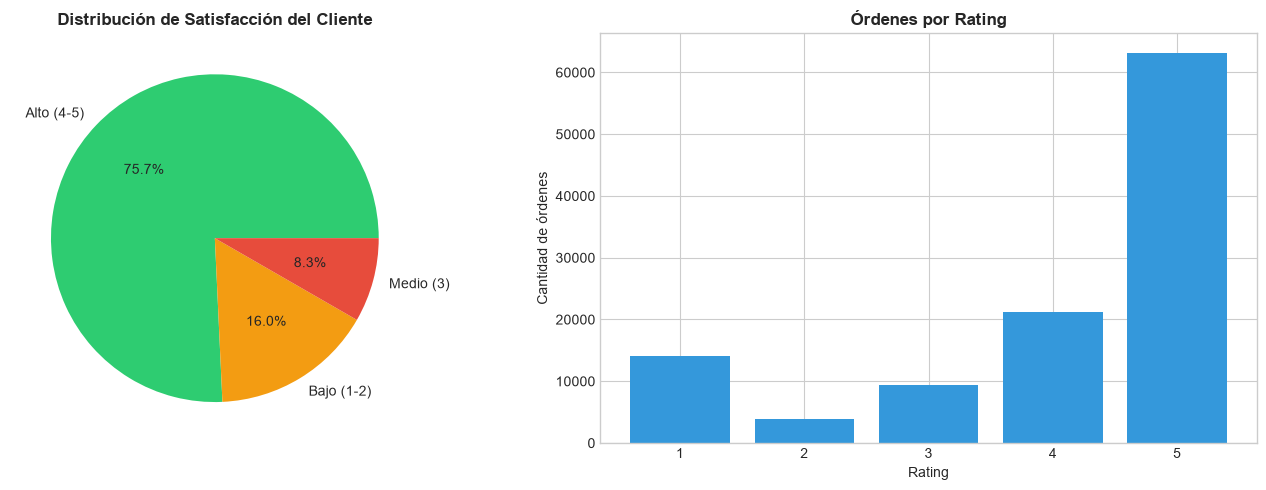

✓ Gráfico 1: Satisfacción del Cliente


In [23]:
# Figura 1: Distribución de Ratings
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
rating_counts = data['rating_category'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#95a5a6']
axes[0].pie(rating_counts.values, labels=rating_counts.index, autopct='%1.1f%%', colors=colors)
axes[0].set_title('Distribución de Satisfacción del Cliente', fontsize=12, fontweight='bold')

# Bar chart
rating_agg = data.groupby('customer_rating')['order_id'].count()
axes[1].bar(rating_agg.index, rating_agg.values, color='#3498db')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Cantidad de órdenes')
axes[1].set_title('Órdenes por Rating', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Gráfico 1: Satisfacción del Cliente")

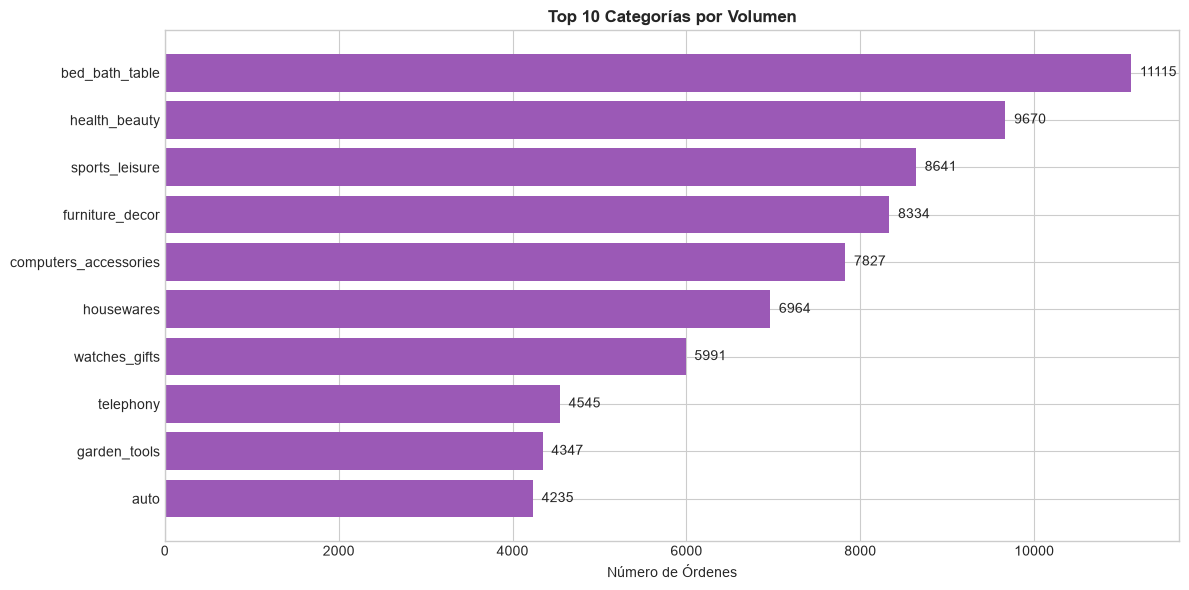

✓ Gráfico 2: Top Categorías


In [24]:
# Figura 2: Top 10 Categorías
fig, ax = plt.subplots(figsize=(12, 6))

top_categories = category_analysis.head(10)['Órdenes'].sort_values()
ax.barh(range(len(top_categories)), top_categories.values, color='#9b59b6')
ax.set_yticks(range(len(top_categories)))
ax.set_yticklabels(top_categories.index)
ax.set_xlabel('Número de Órdenes')
ax.set_title('Top 10 Categorías por Volumen', fontsize=12, fontweight='bold')

# Añadir valores
for i, v in enumerate(top_categories.values):
    ax.text(v + 100, i, str(int(v)), va='center')

plt.tight_layout()
plt.show()

print("✓ Gráfico 2: Top Categorías")

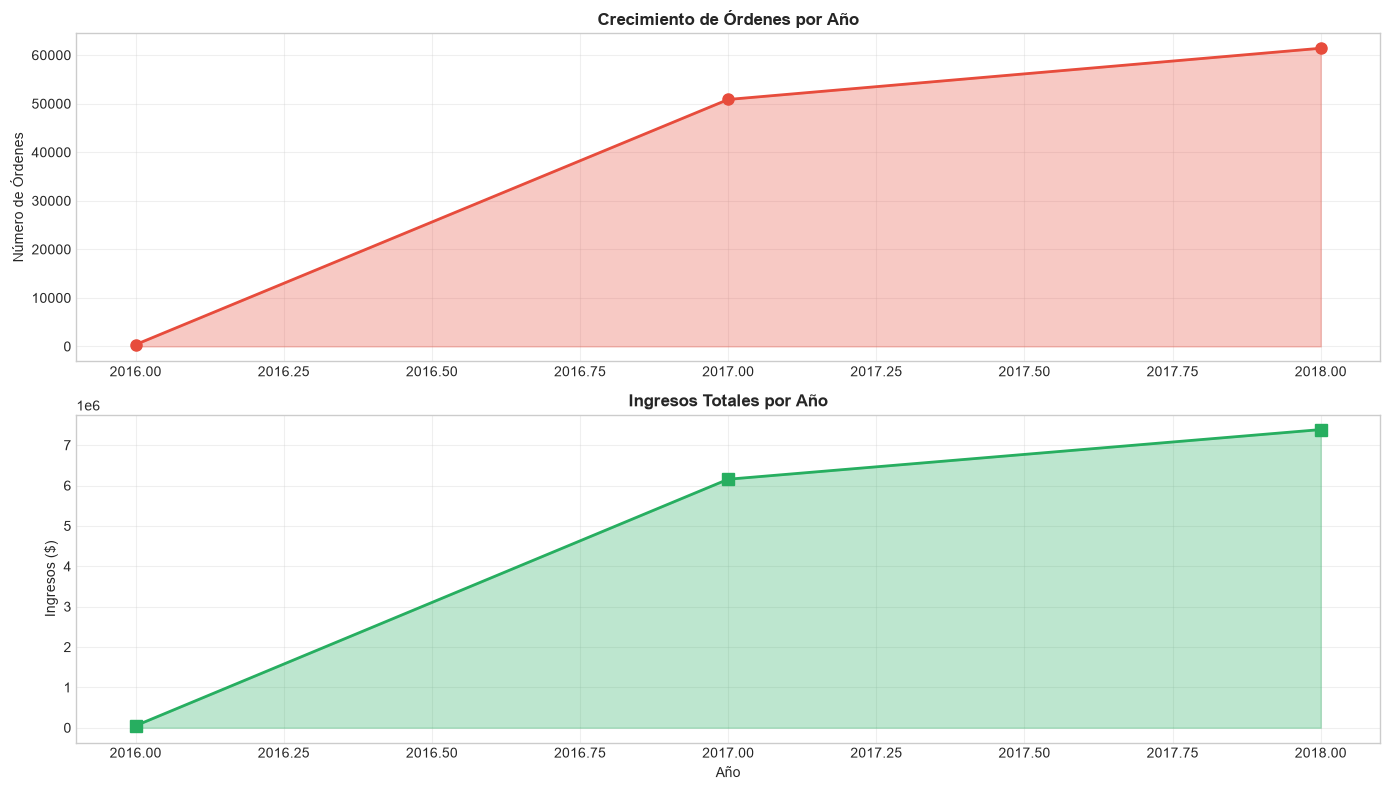

✓ Gráfico 3: Crecimiento Temporal


In [25]:
# Figura 3: Crecimiento Temporal
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Órdenes por año
yearly_orders = data.groupby('year')['order_id'].count()
axes[0].plot(yearly_orders.index, yearly_orders.values, marker='o', linewidth=2, markersize=8, color='#e74c3c')
axes[0].fill_between(yearly_orders.index, yearly_orders.values, alpha=0.3, color='#e74c3c')
axes[0].set_ylabel('Número de Órdenes')
axes[0].set_title('Crecimiento de Órdenes por Año', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Ingresos por año
yearly_revenue = data.groupby('year')['revenue'].sum()
axes[1].plot(yearly_revenue.index, yearly_revenue.values, marker='s', linewidth=2, markersize=8, color='#27ae60')
axes[1].fill_between(yearly_revenue.index, yearly_revenue.values, alpha=0.3, color='#27ae60')
axes[1].set_xlabel('Año')
axes[1].set_ylabel('Ingresos ($)')
axes[1].set_title('Ingresos Totales por Año', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Gráfico 3: Crecimiento Temporal")

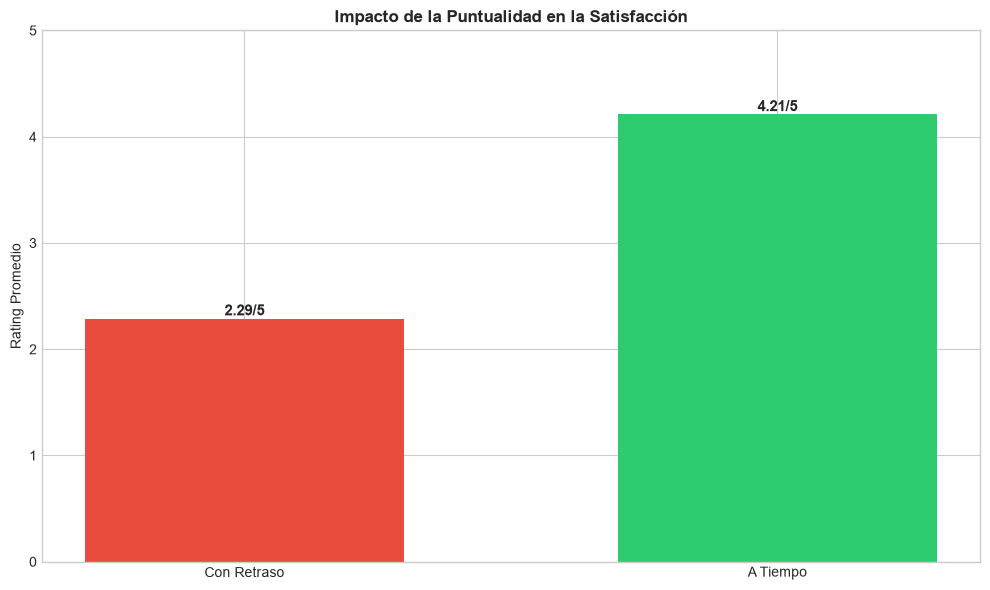

✓ Gráfico 4: Impacto de Entrega


In [26]:
# Figura 4: Impacto de Entrega en Rating
fig, ax = plt.subplots(figsize=(10, 6))

on_time_labels = ['Con Retraso', 'A Tiempo']
on_time_ratings = [
    data[data['on_time_delivery'] == 0]['customer_rating'].mean(),
    data[data['on_time_delivery'] == 1]['customer_rating'].mean()
]

colors = ['#e74c3c', '#2ecc71']
bars = ax.bar(on_time_labels, on_time_ratings, color=colors, width=0.6)

ax.set_ylabel('Rating Promedio')
ax.set_title('Impacto de la Puntualidad en la Satisfacción', fontsize=12, fontweight='bold')
ax.set_ylim([0, 5])

# Añadir valores
for bar, rating in zip(bars, on_time_ratings):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{rating:.2f}/5',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Gráfico 4: Impacto de Entrega")

## 9. GUARDAR DATASET Y ANÁLISIS

In [27]:
# Guardar dataset final
output_path = 'C:/Users/algon/Desktop/TFM/data/processed/'

data.to_csv(f'{output_path}olist_dataset_final.csv', index=False)
print(f"✓ Dataset guardado: {output_path}olist_dataset_final.csv")

# Guardar análisis RFM
rfm_data.to_csv(f'{output_path}rfm_analysis.csv', index=False)
print(f"✓ RFM guardado: {output_path}rfm_analysis.csv")

# Guardar matriz de correlaciones
correlation_matrix.to_csv(f'{output_path}correlation_matrix.csv')
print(f"✓ Correlaciones guardadas: {output_path}correlation_matrix.csv")

# Guardar análisis por categoría
category_analysis.to_csv(f'{output_path}category_analysis.csv')
print(f"✓ Categorías guardadas: {output_path}category_analysis.csv")

# Guardar análisis por estado
state_analysis.to_csv(f'{output_path}state_analysis.csv')
print(f"✓ Estados guardados: {output_path}state_analysis.csv")

print("\n✅ TODOS LOS ARCHIVOS GUARDADOS")

✓ Dataset guardado: C:/Users/algon/Desktop/TFM/data/processed/olist_dataset_final.csv
✓ RFM guardado: C:/Users/algon/Desktop/TFM/data/processed/rfm_analysis.csv
✓ Correlaciones guardadas: C:/Users/algon/Desktop/TFM/data/processed/correlation_matrix.csv
✓ Categorías guardadas: C:/Users/algon/Desktop/TFM/data/processed/category_analysis.csv
✓ Estados guardados: C:/Users/algon/Desktop/TFM/data/processed/state_analysis.csv

✅ TODOS LOS ARCHIVOS GUARDADOS


## 10. RESUMEN EJECUTIVO

In [28]:
print("\n" + "="*70)
print("RESUMEN EJECUTIVO - ANÁLISIS OLIST")
print("="*70)

print(f"\n📊 DATASET:")
print(f"  - Registros: {data.shape[0]:,}")
print(f"  - Columnas: {data.shape[1]}")
print(f"  - Período: {data['order_purchase_timestamp'].min().date()} a {data['order_purchase_timestamp'].max().date()}")

print(f"\n💼 NEGOCIO:")
print(f"  - Órdenes: {data['order_id'].nunique():,}")
print(f"  - Clientes: {data['customer_id'].nunique():,}")
print(f"  - Vendedores: {data['seller_id'].nunique():,}")
print(f"  - Ingresos: ${data['revenue'].sum():,.2f}")

print(f"\n😊 SATISFACCIÓN:")
print(f"  - Rating promedio: {data['customer_rating'].mean():.2f}/5")
print(f"  - % Satisfechos (4-5): {(data['customer_rating'] >= 4).sum() / len(data[data['customer_rating'] > 0]) * 100:.1f}%")

print(f"\n⏱️  OPERACIONES:")
print(f"  - Entregas a tiempo: {data['on_time_delivery'].mean()*100:.1f}%")
print(f"  - Días promedio: {data['delivery_days'].mean():.1f}")

print(f"\n🗺️  GEOGRAFÍA:")
top_state = state_analysis.index[0]
top_state_pct = state_analysis.iloc[0]['Órdenes'] / data['order_id'].nunique() * 100
print(f"  - Top estado: {top_state} ({top_state_pct:.1f}%)")
print(f"  - Cobertura: 27 estados")

print(f"\n📦 PRODUCTOS:")
top_category = category_analysis.index[0]
print(f"  - Top categoría: {top_category}")
print(f"  - Total categorías: {data['product_category'].nunique()}")

print(f"\n👥 CLIENTES:")
print(f"  - VIP: {(rfm_data['customer_segment'] == 'VIP').sum()} ({(rfm_data['customer_segment'] == 'VIP').sum() / len(rfm_data) * 100:.1f}%)")
print(f"  - Frequency media: {rfm_data['frequency'].mean():.2f} compras/cliente")

print(f"\n" + "="*70)
print("✅ ANÁLISIS COMPLETADO")
print("="*70)


RESUMEN EJECUTIVO - ANÁLISIS OLIST

📊 DATASET:
  - Registros: 112,650
  - Columnas: 50
  - Período: 2016-09-04 a 2018-09-03

💼 NEGOCIO:
  - Órdenes: 98,666
  - Clientes: 98,666
  - Vendedores: 3,095
  - Ingresos: $13,591,643.70

😊 SATISFACCIÓN:
  - Rating promedio: 4.03/5
  - % Satisfechos (4-5): 75.5%

⏱️  OPERACIONES:
  - Entregas a tiempo: 90.6%
  - Días promedio: 12.0

🗺️  GEOGRAFÍA:
  - Top estado: SP (48.1%)
  - Cobertura: 27 estados

📦 PRODUCTOS:
  - Top categoría: bed_bath_table
  - Total categorías: 71

👥 CLIENTES:
  - VIP: 24961 (25.3%)
  - Frequency media: 1.14 compras/cliente

✅ ANÁLISIS COMPLETADO
